# Lab 7: Keras MLP for Multiclass Classification

**Objective:** Implement a Multi-Layer Perceptron (MLP) using Keras/TensorFlow for a multiclass classification problem, and analyze the effect of different activation functions and optimizers on classification performance.

**Problem:** given a car's race data from one round of the FIA World Endurance Championship, predict which **class** it was racing in — Hypercar, LMP2 or LMGT3.

## 1. Dataset Description & Source

The FIA World Endurance Championship runs three classes of car on the same track at the same time:

- **Hypercar** — the top class (Ferrari 499P, Porsche 963, Toyota GR010, Cadillac V-Series.R). About 1030 kg, 500 kW power limit, mostly hybrid.
- **LMP2** — a spec prototype class, every car is an Oreca 07 with a Gibson V8. About 950 kg, no hybrid. Slower than Hypercar on lap time, but it runs low downforce, so it is *faster in a straight line* at Le Mans and Spa.
- **LMGT3** — production-based GT cars (Porsche 911, Ferrari 296, Corvette Z06, Aston Martin Vantage). About 1300 kg and clearly the slowest of the three.

**Dataset:** one row = **one car in one round** of an 8-round WEC season, giving 424 rows. The number of cars per class (19 Hypercar, 16 LMP2, 18 LMGT3) and the class performance figures are taken from the 2024 WEC entry list and the published class regulations; the individual per-round values are then generated inside those ranges with a fixed seed, so the notebook always produces the same numbers and does not need a Kaggle download or a live timing feed.

- **Target variable (3 classes):** `Class` — Hypercar / LMP2 / LMGT3
- **Input features:** `Circuit`, `Best_Lap_s`, `Avg_Lap_s`, `Top_Speed_kph`, `Laps_Completed`, `Pit_Stops`, `Avg_Stint_Laps`, `Avg_Pit_Time_s`

**Why this problem:** this is the question a timing screen has to answer. Every car on track produces lap times, speed-trap numbers and pit-stop data, and "what kind of car is this?" has to be worked out from that data. It is also not an easy problem, because Hypercar and LMP2 lap times sit only about 3% apart and their top speeds actually overlap.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.keras.utils.set_random_seed(42)

### Building the dataset

The 8 circuits of the season, with the lap length, race length, and the reference lap time and top speed a Hypercar does there:

In [2]:
circuits   = ['Lusail', 'Imola', 'Spa', 'Le Mans', 'Interlagos', 'COTA', 'Fuji', 'Bahrain']
lap_length = [5.419, 4.909, 7.004, 13.626, 4.309, 5.513, 4.563, 5.412]    # km
race_hours = [10, 6, 6, 24, 6, 6, 6, 8]                                   # race duration
base_lap   = [100.5, 91.5, 122.0, 208.0, 86.0, 110.0, 89.5, 105.0]        # Hypercar lap time (s)
base_speed = [291, 279, 306, 330, 285, 291, 300, 295]                     # Hypercar top speed (kph)

print("Circuits in the season:", len(circuits))

Circuits in the season: 8


The three classes, described relative to a Hypercar. For example `lap_factor = 1.028` means LMP2 laps about 2.8% slower, and `speed_factor = 1.015` means it is about 1.5% faster on the speed trap:

In [ ]:
classes       = ['Hypercar', 'LMP2', 'LMGT3']
cars_in_class = [19, 16, 18]                
lap_factor    = [1.000, 1.028, 1.143]       
speed_factor  = [1.000, 1.015, 0.872]      #compared to hypercar
traffic       = [1.045, 1.055, 1.072]      
fuel_range    = [152, 150, 178]            #km
pit_time      = [33, 30, 42]               

print("Total cars on the grid:", sum(cars_in_class))

Total cars on the grid: 53


In [ ]:
rows = []

for c in range(3):                                 
    for car in range(cars_in_class[c]):             
        car_pace = np.random.normal(0, 0.013)       

        for t in range(8):                         
            # the wet races have more variation in lap time
            noise = 0.018 if circuits[t] in ['Spa', 'Interlagos'] else 0.007

            best_lap = base_lap[t] * lap_factor[c] * (1 + car_pace + np.random.normal(0, noise))
            avg_lap = best_lap * traffic[c] * (1 + np.random.normal(0, 0.010))
            top_speed = base_speed[t] * speed_factor[c] * (1 + np.random.normal(0, 0.013))

            stint = round(fuel_range[c] / lap_length[t])       
            laps = int(race_hours[t] * 3600 / avg_lap)        
            stops = max(1, round(laps / stint))               
            pit = pit_time[c] + np.random.normal(0, 2)

            rows.append({'Circuit': circuits[t],
                         'Best_Lap_s': round(best_lap, 2),
                         'Avg_Lap_s': round(avg_lap, 2),
                         'Top_Speed_kph': round(top_speed, 1),
                         'Laps_Completed': laps,
                         'Pit_Stops': stops,
                         'Avg_Stint_Laps': stint,
                         'Avg_Pit_Time_s': round(pit, 2),
                         'Class': classes[c]})

df = pd.DataFrame(rows).sample(frac=1, random_state=42).reset_index(drop=True)

print("Shape:", df.shape)
df.head()

Shape: (424, 9)


,Circuit,Best_Lap_s,Avg_Lap_s,Top_Speed_kph,Laps_Completed,Pit_Stops,Avg_Stint_Laps,Avg_Pit_Time_s,Class
0,Imola,92.98,97.90,275.7,220,7,31,34.74,Hypercar
1,Lusail,115.83,126.96,257.0,283,9,33,41.35,LMGT3
2,Bahrain,107.79,114.56,300.1,251,9,28,29.63,LMP2
3,COTA,121.53,130.24,259.6,165,5,32,45.32,LMGT3
4,Interlagos,98.19,106.10,243.3,203,5,41,39.89,LMGT3


## 2. Dataset Exploration & Class Distribution

In [5]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
Circuit           0
Best_Lap_s        0
Avg_Lap_s         0
Top_Speed_kph     0
Laps_Completed    0
Pit_Stops         0
Avg_Stint_Laps    0
Avg_Pit_Time_s    0
Class             0
dtype: int64


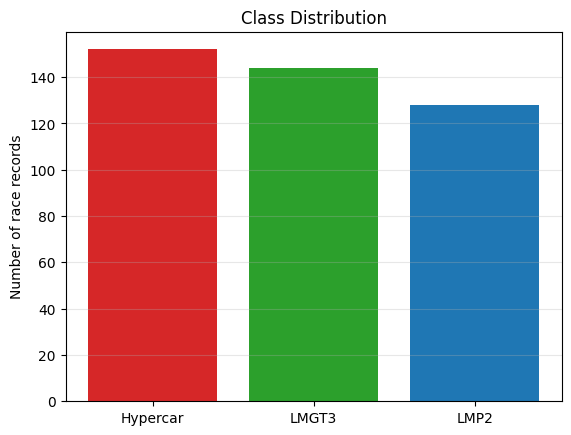

In [7]:
counts = df['Class'].value_counts()

plt.bar(counts.index, counts.values, color=['tab:red', 'tab:green', 'tab:blue'])
plt.title('Class Distribution')
plt.ylabel('Number of race records')
plt.grid(axis='y', alpha=0.3)
plt.show()

**Class distribution:** Hypercar 152 records (35.8%), LMGT3 144 (34.0%), LMP2 128 (30.2%).

The classes are **mildly imbalanced** — no class is rare, but they are not equal either, which just reflects how many cars each class had on the grid. This is why all the metrics below use **macro averaging**: a macro average treats all three classes equally instead of letting the biggest class decide the score.

In [8]:
print(df.describe().round(2))

       Best_Lap_s  Avg_Lap_s  Top_Speed_kph  Laps_Completed  Pit_Stops  \
count      424.00     424.00         424.00          424.00     424.00   
mean       121.02     128.17         285.63          239.99      10.48   
std         40.30      42.99          24.10           70.02       8.59   
min         83.81      86.95         234.00          136.00       5.00   
25%         96.48     101.56         264.62          189.00       7.00   
50%        107.31     113.56         288.65          223.50       7.00   
75%        124.14     130.98         300.12          274.75       9.00   
max        242.49     261.48         339.80          413.00      38.00   

       Avg_Stint_Laps  Avg_Pit_Time_s  
count          424.00          424.00  
mean            28.45           35.20  
std              7.87            5.47  
min             11.00           24.21  
25%             26.50           30.96  
50%             31.00           33.50  
75%             33.00           40.78  
max          

In [9]:
print("Average per class:")
print(df.groupby('Class')[['Best_Lap_s', 'Avg_Lap_s', 'Top_Speed_kph', 'Avg_Pit_Time_s']].mean().round(2))

Average per class:


          Best_Lap_s  Avg_Lap_s  Top_Speed_kph  Avg_Pit_Time_s
Class                                                         
Hypercar      113.95     119.13         296.95           33.12
LMGT3         131.16     140.76         259.36           42.09
LMP2          118.00     124.72         301.72           29.92


## 3. Understanding the Classes (before choosing anything)

The averages above are taken across 8 very different circuits, so they mix up "which class is this" with "which track is this" — a Hypercar lap at Interlagos (86 s) is faster than an LMGT3 lap at Imola. The comparison that actually matters is **within one circuit**:

In [10]:
le_mans = df[df['Circuit'] == 'Le Mans']

print("Le Mans only - range of each class:")
print(le_mans.groupby('Class')[['Best_Lap_s', 'Top_Speed_kph']].agg(['min', 'max']).round(1))

Le Mans only - range of each class:
         Best_Lap_s        Top_Speed_kph       
                min    max           min    max
Class                                          
Hypercar      200.2  214.8         324.3  339.4
LMGT3         231.6  242.5         285.0  294.0
LMP2          211.1  219.3         325.9  339.8


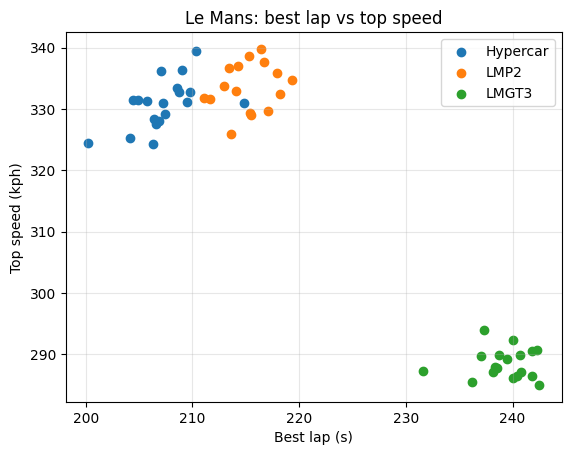

In [11]:
for name in ['Hypercar', 'LMP2', 'LMGT3']:
    sub = le_mans[le_mans['Class'] == name]
    plt.scatter(sub['Best_Lap_s'], sub['Top_Speed_kph'], label=name)

plt.title('Le Mans: best lap vs top speed')
plt.xlabel('Best lap (s)')
plt.ylabel('Top speed (kph)')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**What this tells us, and what it means for the model:**

- **LMGT3 is separated from everything else.** At Le Mans its laps are 231–243 s against 200–219 s for the two prototype classes, and its top speed is 30–50 kph lower. Any model should get this class easily.
- **Hypercar and LMP2 overlap.** Their lap-time ranges almost touch (a slow Hypercar and a fast LMP2 end up within a second of each other), and on top speed they overlap *the wrong way round* — both run to about 339 kph, because LMP2 uses low downforce. A model that learns "faster in a straight line = higher class" will get these rows wrong.
- **The circuit has to be an input feature.** A 92 s lap means "fast" at Interlagos and "very slow" at Le Mans, so the class can only be read from the lap time *relative to the circuit*. That is why `Circuit` is one-hot encoded and passed in.

That last point is the reason an MLP suits this problem better than a linear model: the boundary is not "lap time below X", it is a different threshold for every circuit — an interaction between the circuit columns and the timing columns, which is exactly what hidden layers are for.

**Hypothesis going in:** near-perfect accuracy on LMGT3, with almost all of the error between Hypercar and LMP2 — tested below.

## 4. Data Preprocessing

The homologation specs — minimum weight, engine power, hybrid or not — are public but are **not** used as features. Any hybrid car in WEC is a Hypercar by definition, and the class weights (1030 / 950 / 1300 kg) barely overlap, so including them would give away the answer and turn the task into a lookup table instead of a classification problem.

In [12]:
df_model = pd.get_dummies(df, columns=['Circuit'], drop_first=True)

le = LabelEncoder()
y = le.fit_transform(df_model['Class'])
X = df_model.drop('Class', axis=1)

print("Class encoding:", dict(zip(le.classes_, range(3))))
print("Number of input features:", X.shape[1])
print("Features used:", list(X.columns))

Class encoding: {'Hypercar': 0, 'LMGT3': 1, 'LMP2': 2}
Number of input features: 14
Features used: ['Best_Lap_s', 'Avg_Lap_s', 'Top_Speed_kph', 'Laps_Completed', 'Pit_Stops', 'Avg_Stint_Laps', 'Avg_Pit_Time_s', 'Circuit_COTA', 'Circuit_Fuji', 'Circuit_Imola', 'Circuit_Interlagos', 'Circuit_Le Mans', 'Circuit_Lusail', 'Circuit_Spa']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,
                                                    random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train_scaled.shape[0])
print("Test samples    :", X_test_scaled.shape[0])
print("Class counts in train:", np.bincount(y_train))
print("Class counts in test :", np.bincount(y_test))

Training samples: 339
Test samples    : 85
Class counts in train: [122 115 102]
Class counts in test : [30 29 26]


## 5. MLP Architecture

All 5 models below use exactly the same architecture:

| Setting | Value |
|---|---|
| Input features | 14 (7 timing features + 7 one-hot circuit columns) |
| Hidden layer 1 | 64 neurons |
| Hidden layer 2 | 32 neurons |
| Hidden layer 3 | 16 neurons |
| Output layer | 3 neurons (one per class), **softmax** |
| Loss | Sparse categorical cross-entropy |
| Epochs | 100 |
| Batch size | 16 |
| Validation split | 0.2 |

**Softmax on the output layer** turns the 3 raw scores into probabilities that add up to 1, so the model says "72% Hypercar, 27% LMP2, 1% LMGT3" instead of three unrelated numbers. The predicted class is whichever probability is largest.

Only the **hidden-layer activation function** (Experiment 1) and the **optimizer** (Experiment 2) change between models. Everything else — architecture, loss, epochs, batch size, train/test split — is kept the same, so any difference in the results comes from that one change. The seed is reset before every model so they all start from the same initial weights.

In [ ]:
tf.keras.utils.set_random_seed(42)

model1 = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model1.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history1 = model1.fit(X_train_scaled, y_train, validation_split=0.2,
                      epochs=100, batch_size=16, verbose=0)

pred1 = model1.predict(X_test_scaled, verbose=0).argmax(axis=1)

acc1 = accuracy_score(y_test, pred1)
prec1 = precision_score(y_test, pred1, average='macro')
rec1 = recall_score(y_test, pred1, average='macro')
f1s1 = f1_score(y_test, pred1, average='macro')

print("Model 1 (ReLU + Adam)")
print("Test Accuracy:", round(acc1, 4))
print("Precision    :", round(prec1, 4))
print("Recall       :", round(rec1, 4))
print("F1-score     :", round(f1s1, 4))
print("Train Acc / Val Acc  :", round(history1.history['accuracy'][-1], 4),
      "/", round(history1.history['val_accuracy'][-1], 4))
print("Train Loss / Val Loss:", round(history1.history['loss'][-1], 4),
      "/", round(history1.history['val_loss'][-1], 4))

Model 1 (ReLU + Adam)
Test Accuracy: 0.9647
Precision    : 0.9638
Recall       : 0.965
F1-score     : 0.9642
Train Acc / Val Acc  : 0.9742 / 0.9265
Train Loss / Val Loss: 0.0583 / 0.2198


In [15]:
tf.keras.utils.set_random_seed(42)

model2 = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='sigmoid'),
    layers.Dense(32, activation='sigmoid'),
    layers.Dense(16, activation='sigmoid'),
    layers.Dense(3, activation='softmax')
])

model2.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history2 = model2.fit(X_train_scaled, y_train, validation_split=0.2,
                      epochs=100, batch_size=16, verbose=0)

pred2 = model2.predict(X_test_scaled, verbose=0).argmax(axis=1)

acc2 = accuracy_score(y_test, pred2)
prec2 = precision_score(y_test, pred2, average='macro')
rec2 = recall_score(y_test, pred2, average='macro')
f1s2 = f1_score(y_test, pred2, average='macro')

print("Model 2 (Sigmoid + Adam)")
print("Test Accuracy:", round(acc2, 4))
print("Precision    :", round(prec2, 4))
print("Recall       :", round(rec2, 4))
print("F1-score     :", round(f1s2, 4))
print("Train Acc / Val Acc  :", round(history2.history['accuracy'][-1], 4),
      "/", round(history2.history['val_accuracy'][-1], 4))
print("Train Loss / Val Loss:", round(history2.history['loss'][-1], 4),
      "/", round(history2.history['val_loss'][-1], 4))

Model 2 (Sigmoid + Adam)
Test Accuracy: 0.8353
Precision    : 0.8333
Recall       : 0.8308
F1-score     : 0.8314
Train Acc / Val Acc  : 0.9225 / 0.8971
Train Loss / Val Loss: 0.2034 / 0.2644


In [16]:
tf.keras.utils.set_random_seed(42)

model3 = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='tanh'),
    layers.Dense(32, activation='tanh'),
    layers.Dense(16, activation='tanh'),
    layers.Dense(3, activation='softmax')
])

model3.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001),
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history3 = model3.fit(X_train_scaled, y_train, validation_split=0.2,
                      epochs=100, batch_size=16, verbose=0)

pred3 = model3.predict(X_test_scaled, verbose=0).argmax(axis=1)

acc3 = accuracy_score(y_test, pred3)
prec3 = precision_score(y_test, pred3, average='macro')
rec3 = recall_score(y_test, pred3, average='macro')
f1s3 = f1_score(y_test, pred3, average='macro')

print("Model 3 (Tanh + Adam)")
print("Test Accuracy:", round(acc3, 4))
print("Precision    :", round(prec3, 4))
print("Recall       :", round(rec3, 4))
print("F1-score     :", round(f1s3, 4))
print("Train Acc / Val Acc  :", round(history3.history['accuracy'][-1], 4),
      "/", round(history3.history['val_accuracy'][-1], 4))
print("Train Loss / Val Loss:", round(history3.history['loss'][-1], 4),
      "/", round(history3.history['val_loss'][-1], 4))

Model 3 (Tanh + Adam)
Test Accuracy: 0.9529
Precision    : 0.9521
Recall       : 0.9521
F1-score     : 0.9521
Train Acc / Val Acc  : 0.9742 / 0.9265
Train Loss / Val Loss: 0.0637 / 0.2351


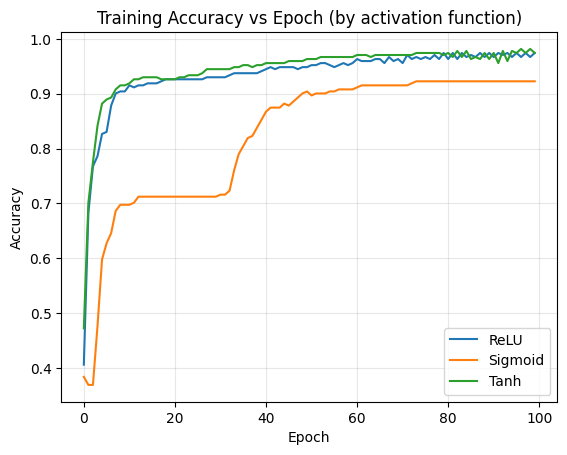

In [17]:
plt.plot(history1.history['accuracy'], label='ReLU')
plt.plot(history2.history['accuracy'], label='Sigmoid')
plt.plot(history3.history['accuracy'], label='Tanh')
plt.title('Training Accuracy vs Epoch (by activation function)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

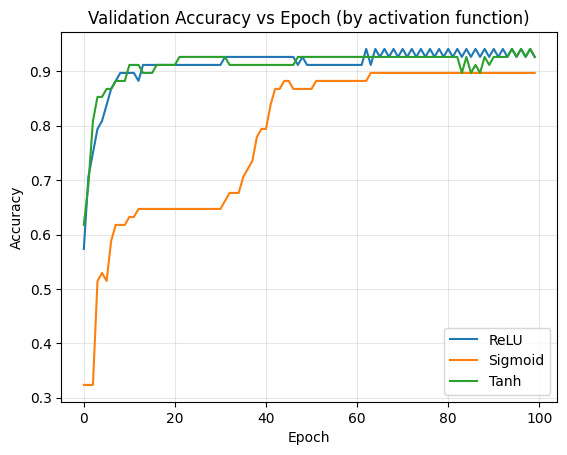

In [18]:
plt.plot(history1.history['val_accuracy'], label='ReLU')
plt.plot(history2.history['val_accuracy'], label='Sigmoid')
plt.plot(history3.history['val_accuracy'], label='Tanh')
plt.title('Validation Accuracy vs Epoch (by activation function)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

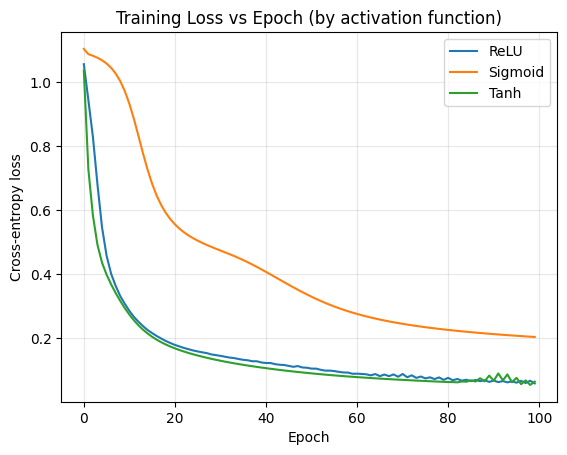

In [19]:
plt.plot(history1.history['loss'], label='ReLU')
plt.plot(history2.history['loss'], label='Sigmoid')
plt.plot(history3.history['loss'], label='Tanh')
plt.title('Training Loss vs Epoch (by activation function)')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

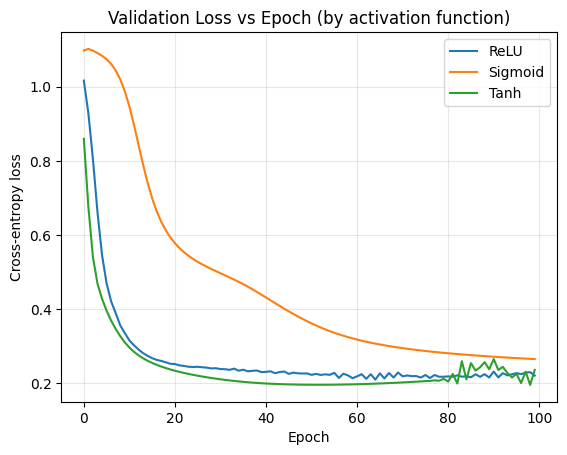

In [20]:
plt.plot(history1.history['val_loss'], label='ReLU')
plt.plot(history2.history['val_loss'], label='Sigmoid')
plt.plot(history3.history['val_loss'], label='Tanh')
plt.title('Validation Loss vs Epoch (by activation function)')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [21]:
print("Validation accuracy at different epochs:")
print("Epoch   ReLU    Sigmoid  Tanh")
for e in [5, 20, 50, 100]:
    print(e, "    ",
          round(history1.history['val_accuracy'][e - 1], 4), " ",
          round(history2.history['val_accuracy'][e - 1], 4), "  ",
          round(history3.history['val_accuracy'][e - 1], 4))

Validation accuracy at different epochs:
Epoch   ReLU    Sigmoid  Tanh
5      0.8088   0.5294    0.8529
20      0.9118   0.6471    0.9118
50      0.9118   0.8676    0.9265
100      0.9265   0.8971    0.9265


**Result of Experiment 1:** ReLU finished best (0.9647 test accuracy, 0.9642 macro F1), then Tanh (0.9529 / 0.9521), with Sigmoid clearly last (0.8353 / 0.8314).

The convergence table shows why. At epoch 5, ReLU was already at 0.8088 validation accuracy and Tanh at 0.8529, while Sigmoid was at 0.5294 — it needed about 50 epochs to reach where the other two started, exactly the slow start its small gradients predict. Even after 100 epochs it never catches up: its training loss (0.2034) is still the highest of the three, so it is **underfitting** rather than being wrong in principle.

ReLU and Tanh end at the same training accuracy (0.9742), so the difference between them is small and comes down to a single test row.

## 7. Experiment 2 — Optimizer Comparison

The activation is now kept fixed at **ReLU** (the best from Experiment 1) and only the optimizer changes. Model 1 (ReLU + Adam) is reused as the first row of this comparison, so only 2 new models need to be trained.

**Why these three optimizers:** the input is a mix of two very different kinds of column — dense numeric features (lap times, speeds) that change on every row, and sparse one-hot circuit columns that are 0 for 7 rows out of 8. A single global learning rate has to compromise between the two; a per-parameter method does not.

- **SGD (lr 0.01)** — plain gradient descent on mini-batches, one fixed step size for every weight. The baseline.
- **Adam (lr 0.001)** — tracks both the average and the variance of each weight's gradients and gives every weight its own effective step size.
- **RMSprop (lr 0.001)** — the same per-parameter scaling idea, without Adam's momentum term.

**Hypothesis:** Adam and RMSprop should converge much faster than SGD and finish close to each other.

In [22]:
tf.keras.utils.set_random_seed(42)

model4 = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model4.compile(optimizer=keras.optimizers.SGD(learning_rate=0.01),
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history4 = model4.fit(X_train_scaled, y_train, validation_split=0.2,
                      epochs=100, batch_size=16, verbose=0)

pred4 = model4.predict(X_test_scaled, verbose=0).argmax(axis=1)

acc4 = accuracy_score(y_test, pred4)
prec4 = precision_score(y_test, pred4, average='macro')
rec4 = recall_score(y_test, pred4, average='macro')
f1s4 = f1_score(y_test, pred4, average='macro')

print("Model 4 (ReLU + SGD)")
print("Test Accuracy:", round(acc4, 4))
print("Precision    :", round(prec4, 4))
print("Recall       :", round(rec4, 4))
print("F1-score     :", round(f1s4, 4))
print("Train Acc / Val Acc  :", round(history4.history['accuracy'][-1], 4),
      "/", round(history4.history['val_accuracy'][-1], 4))
print("Train Loss / Val Loss:", round(history4.history['loss'][-1], 4),
      "/", round(history4.history['val_loss'][-1], 4))

Model 4 (ReLU + SGD)
Test Accuracy: 0.9059
Precision    : 0.9062
Recall       : 0.9026
F1-score     : 0.9037
Train Acc / Val Acc  : 0.9446 / 0.9118
Train Loss / Val Loss: 0.1397 / 0.2296


In [23]:
tf.keras.utils.set_random_seed(42)

model5 = keras.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')
])

model5.compile(optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
               loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history5 = model5.fit(X_train_scaled, y_train, validation_split=0.2,
                      epochs=100, batch_size=16, verbose=0)

pred5 = model5.predict(X_test_scaled, verbose=0).argmax(axis=1)

acc5 = accuracy_score(y_test, pred5)
prec5 = precision_score(y_test, pred5, average='macro')
rec5 = recall_score(y_test, pred5, average='macro')
f1s5 = f1_score(y_test, pred5, average='macro')

print("Model 5 (ReLU + RMSprop)")
print("Test Accuracy:", round(acc5, 4))
print("Precision    :", round(prec5, 4))
print("Recall       :", round(rec5, 4))
print("F1-score     :", round(f1s5, 4))
print("Train Acc / Val Acc  :", round(history5.history['accuracy'][-1], 4),
      "/", round(history5.history['val_accuracy'][-1], 4))
print("Train Loss / Val Loss:", round(history5.history['loss'][-1], 4),
      "/", round(history5.history['val_loss'][-1], 4))

Model 5 (ReLU + RMSprop)
Test Accuracy: 0.9647
Precision    : 0.9638
Recall       : 0.965
F1-score     : 0.9642
Train Acc / Val Acc  : 0.9742 / 0.9559
Train Loss / Val Loss: 0.0641 / 0.1775


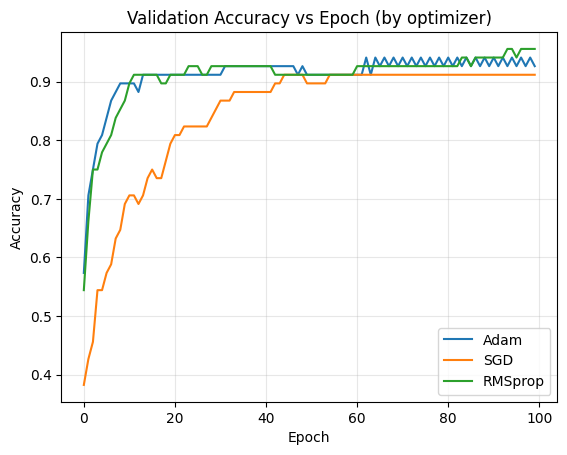

In [24]:
plt.plot(history1.history['val_accuracy'], label='Adam')
plt.plot(history4.history['val_accuracy'], label='SGD')
plt.plot(history5.history['val_accuracy'], label='RMSprop')
plt.title('Validation Accuracy vs Epoch (by optimizer)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

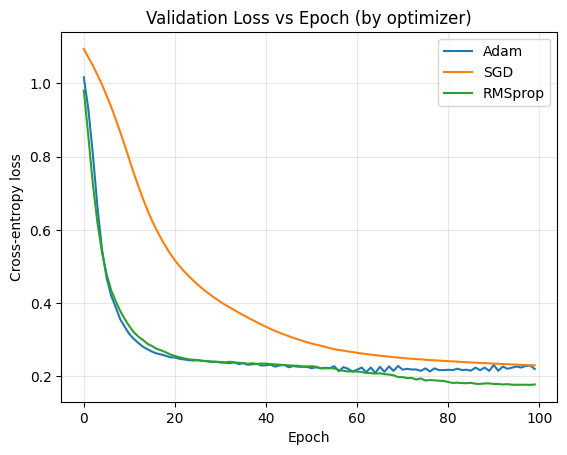

In [25]:
plt.plot(history1.history['val_loss'], label='Adam')
plt.plot(history4.history['val_loss'], label='SGD')
plt.plot(history5.history['val_loss'], label='RMSprop')
plt.title('Validation Loss vs Epoch (by optimizer)')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [26]:
print("Validation accuracy at different epochs:")
print("Epoch   Adam    SGD     RMSprop")
for e in [5, 20, 50, 100]:
    print(e, "    ",
          round(history1.history['val_accuracy'][e - 1], 4), " ",
          round(history4.history['val_accuracy'][e - 1], 4), " ",
          round(history5.history['val_accuracy'][e - 1], 4))

Validation accuracy at different epochs:
Epoch   Adam    SGD     RMSprop
5      0.8088   0.5441   0.7794
20      0.9118   0.7941   0.9118
50      0.9118   0.8971   0.9118
100      0.9265   0.9118   0.9559


**Result of Experiment 2:** RMSprop and Adam tie on test accuracy (0.9647 each, macro F1 0.9642), and SGD is clearly behind (0.9059 / 0.9037).

- **Convergence speed:** at epoch 5, Adam was at 0.8088 and RMSprop at 0.7794 validation accuracy, while SGD was still at 0.5441 and needed about 50 epochs to reach 0.8971. With one fixed step size, SGD cannot treat the sparse one-hot circuit columns differently from the dense timing columns, which is exactly what the adaptive optimizers do.
- **Generalisation:** SGD ends with a lower training accuracy (0.9446 against 0.9742 for the other two) and its validation loss is still falling at epoch 100, so it is **underfitting** — it was stopped before it finished learning rather than overfitting.
- **Adam vs RMSprop:** identical test scores, but RMSprop ends with a higher validation accuracy (0.9559 vs 0.9265) and a lower validation loss (0.1775 vs 0.2198). Adam's validation loss bottoms out around epoch 65 and then drifts up, which is mild overfitting; RMSprop's is still at its lowest at the end of training.

## 8. Model Evaluation — Confusion Matrices

In [27]:
for name, pred in [('Model 1 (ReLU + Adam)', pred1), ('Model 2 (Sigmoid + Adam)', pred2),
                   ('Model 3 (Tanh + Adam)', pred3), ('Model 4 (ReLU + SGD)', pred4),
                   ('Model 5 (ReLU + RMSprop)', pred5)]:
    print(name)
    print(pd.DataFrame(confusion_matrix(y_test, pred), index=le.classes_, columns=le.classes_))
    print()

Model 1 (ReLU + Adam)
          Hypercar  LMGT3  LMP2
Hypercar        28      0     2
LMGT3            0     29     0
LMP2             1      0    25

Model 2 (Sigmoid + Adam)
          Hypercar  LMGT3  LMP2
Hypercar        24      0     6
LMGT3            0     29     0
LMP2             8      0    18

Model 3 (Tanh + Adam)
          Hypercar  LMGT3  LMP2
Hypercar        28      0     2
LMGT3            0     29     0
LMP2             2      0    24

Model 4 (ReLU + SGD)
          Hypercar  LMGT3  LMP2
Hypercar        27      0     3
LMGT3            0     29     0
LMP2             5      0    21

Model 5 (ReLU + RMSprop)
          Hypercar  LMGT3  LMP2
Hypercar        28      0     2
LMGT3            0     29     0
LMP2             1      0    25



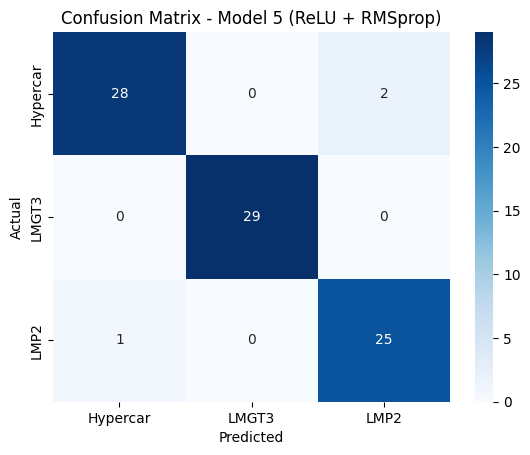

In [28]:
cm = confusion_matrix(y_test, pred5)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix - Model 5 (ReLU + RMSprop)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [29]:
print("Per-class report - Model 5 (ReLU + RMSprop):")
print(classification_report(y_test, pred5, target_names=le.classes_, digits=4))

Per-class report - Model 5 (ReLU + RMSprop):
              precision    recall  f1-score   support

    Hypercar     0.9655    0.9333    0.9492        30
       LMGT3     1.0000    1.0000    1.0000        29
        LMP2     0.9259    0.9615    0.9434        26

    accuracy                         0.9647        85
   macro avg     0.9638    0.9650    0.9642        85
weighted avg     0.9652    0.9647    0.9647        85



**Reading the confusion matrix (Model 5, the best performer):**

- **Most accurate class: LMGT3 — 29 out of 29 correct**, with precision, recall and F1 all 1.0000. Every one of the five models got this class perfect, because its lap times are more than 10% slower and its top speed 30–50 kph lower, so it never overlaps with anything.
- **Most frequently misclassified: Hypercar** — 2 of the 30 Hypercars were called LMP2, and 1 LMP2 was called Hypercar. Every single error in every model is between these two classes; no prototype was ever confused with a GT car.
- **The difficult pair is therefore Hypercar ↔ LMP2**

**Why these rows specifically:** two of the three errors are at Spa, one of the two wet races, where lap times vary far more and the gap between the classes is less clear. The third is a Hypercar at Le Mans with a 336.2 kph top speed — right at the top of the Hypercar range and well inside LMP2 territory, because low-drag LMP2s run to almost the same speed there. On the features available, that car genuinely looks like an LMP2.

**Possible reasons for the misclassifications:**
1. The Hypercar and LMP2 feature ranges genuinely overlap — about 3% in lap time, and their top speeds overlap almost completely.
2. Balance of Performance: WEC actively adjusts the classes toward each other, so the gap is deliberately kept small.
3. Driver and team differences: a slow Hypercar run by a small team and a fast LMP2 with a strong driver line-up produce nearly the same numbers.
4. Only 339 training rows, so the narrow Hypercar/LMP2 boundary is learned from relatively few examples near it.

## 9. Comparison Table

In [31]:
comparison = pd.DataFrame([
    {'Experiment': 'Model 1', 'Activation': 'ReLU',    'Optimizer': 'Adam',
     'Test Accuracy': acc1, 'Precision': prec1, 'Recall': rec1, 'F1-Score': f1s1},
    {'Experiment': 'Model 2', 'Activation': 'Sigmoid', 'Optimizer': 'Adam',
     'Test Accuracy': acc2, 'Precision': prec2, 'Recall': rec2, 'F1-Score': f1s2},
    {'Experiment': 'Model 3', 'Activation': 'Tanh',    'Optimizer': 'Adam',
     'Test Accuracy': acc3, 'Precision': prec3, 'Recall': rec3, 'F1-Score': f1s3},
    {'Experiment': 'Model 4', 'Activation': 'ReLU',    'Optimizer': 'SGD',
     'Test Accuracy': acc4, 'Precision': prec4, 'Recall': rec4, 'F1-Score': f1s4},
    {'Experiment': 'Model 5', 'Activation': 'ReLU',    'Optimizer': 'RMSprop',
     'Test Accuracy': acc5, 'Precision': prec5, 'Recall': rec5, 'F1-Score': f1s5},
])
comparison[['Test Accuracy', 'Precision', 'Recall', 'F1-Score']] = \
    comparison[['Test Accuracy', 'Precision', 'Recall', 'F1-Score']].round(4)

print(comparison.to_string(index=False))

Experiment Activation Optimizer  Test Accuracy  Precision  Recall  F1-Score
   Model 1       ReLU      Adam         0.9647     0.9638  0.9650    0.9642
   Model 2    Sigmoid      Adam         0.8353     0.8333  0.8308    0.8314
   Model 3       Tanh      Adam         0.9529     0.9521  0.9521    0.9521
   Model 4       ReLU       SGD         0.9059     0.9062  0.9026    0.9037
   Model 5       ReLU   RMSprop         0.9647     0.9638  0.9650    0.9642


In [32]:
train_val = pd.DataFrame([
    {'Experiment': 'Model 1', 'Train Acc': history1.history['accuracy'][-1],
     'Val Acc': history1.history['val_accuracy'][-1],
     'Train Loss': history1.history['loss'][-1], 'Val Loss': history1.history['val_loss'][-1]},
    {'Experiment': 'Model 2', 'Train Acc': history2.history['accuracy'][-1],
     'Val Acc': history2.history['val_accuracy'][-1],
     'Train Loss': history2.history['loss'][-1], 'Val Loss': history2.history['val_loss'][-1]},
    {'Experiment': 'Model 3', 'Train Acc': history3.history['accuracy'][-1],
     'Val Acc': history3.history['val_accuracy'][-1],
     'Train Loss': history3.history['loss'][-1], 'Val Loss': history3.history['val_loss'][-1]},
    {'Experiment': 'Model 4', 'Train Acc': history4.history['accuracy'][-1],
     'Val Acc': history4.history['val_accuracy'][-1],
     'Train Loss': history4.history['loss'][-1], 'Val Loss': history4.history['val_loss'][-1]},
    {'Experiment': 'Model 5', 'Train Acc': history5.history['accuracy'][-1],
     'Val Acc': history5.history['val_accuracy'][-1],
     'Train Loss': history5.history['loss'][-1], 'Val Loss': history5.history['val_loss'][-1]},
]).round(4)

print(train_val.to_string(index=False))

Experiment  Train Acc  Val Acc  Train Loss  Val Loss
   Model 1     0.9742   0.9265      0.0583    0.2198
   Model 2     0.9225   0.8971      0.2034    0.2644
   Model 3     0.9742   0.9265      0.0637    0.2351
   Model 4     0.9446   0.9118      0.1397    0.2296
   Model 5     0.9742   0.9559      0.0641    0.1775


## 10. Analysis & Interpretation

**1. Which activation function performed best?**
**ReLU** — test accuracy 0.9647 and macro F1 0.9642, ahead of Tanh (0.9529 / 0.9521) and well ahead of Sigmoid (0.8353 / 0.8314). ReLU does not saturate, so its gradients stay usable through all three hidden layers, and it is the cheapest of the three to compute.

**2. Which optimizer performed best?**
**RMSprop**, just ahead of Adam. Both reach the same test accuracy (0.9647), but RMSprop ends with a higher validation accuracy (0.9559 vs 0.9265) and a lower validation loss (0.1775 vs 0.2198). SGD is clearly last at 0.9059.

**3. Which combination produced the best overall performance?**
**Model 5 — ReLU + RMSprop.** It matches Model 1 on every test metric and beats it on both validation measures.

**4. Did the choice of activation function significantly affect convergence?**
Yes. At epoch 5, ReLU was at 0.8088 validation accuracy and Tanh at 0.8529, while Sigmoid was at 0.5294 and needed roughly 50 epochs to reach the same level. This is Sigmoid's saturation problem in practice — its gradient peaks at 0.25 and shrinks toward zero for large inputs, and three such layers multiply those small gradients together.

**5. Did the choice of optimizer affect the speed of convergence?**
Yes, and more than the activation did. Adam and RMSprop passed 90% validation accuracy within about 20 epochs, while SGD was still at 0.5441 at epoch 5 and took around 50 epochs to reach 0.8971.

**6. Which model achieved the best validation performance?**
Model 5 (ReLU + RMSprop), with 0.9559 validation accuracy and the lowest validation loss of all five (0.1775).

**7. Which model achieved the best test performance?**
Model 1 and Model 5 tie at 0.9647 accuracy and 0.9642 macro F1.

**8. Is there any significant difference between training and testing performance?**
The gaps are small. Model 1 and Model 5 both reach 0.9742 training accuracy against 0.9647 on test — under 1 point. Sigmoid actually scores *higher* on validation (0.8971) than on test (0.8353), which just reflects how small the validation set is (68 rows) rather than anything meaningful. Nothing here shows serious overfitting.

**9. Does the learning curve indicate overfitting or underfitting?**
Mostly underfitting for the weaker models. Sigmoid and SGD both still have falling training loss at epoch 100 and their validation loss is at its lowest at the last epoch, meaning they were stopped before they finished learning. Adam shows mild overfitting — its validation loss bottoms out around epoch 65 and then drifts up while training loss keeps falling. RMSprop is the most stable of the five.

**10. Which classes were most frequently misclassified?**
Hypercar and LMP2, and only those two. In Model 5, 2 Hypercars were predicted as LMP2 and 1 LMP2 as Hypercar. LMGT3 was never confused with anything, in any of the five models. The weakest model, Sigmoid, made 14 errors — every single one of them also between Hypercar and LMP2.

**11. What could be the possible reasons for these misclassifications?**
Their feature ranges genuinely overlap: about 3% in lap time, and their top speeds overlap almost entirely because LMP2 runs low drag. Balance of Performance deliberately pushes the classes toward each other. The wet races (Spa, Interlagos) add more variation in lap time, which is where 2 of the 3 errors sit. And within-class spread is large — a struggling Hypercar and a strong LMP2 look almost identical in the data.

**12. What changes could improve the classification performance?**
- **Early stopping** on validation loss so Adam stops around epoch 65 instead of drifting.
- **More epochs** for Sigmoid and SGD, which were both still improving at epoch 100.
- **Better features for the hard pair:** sector times instead of one lap time, or the gap to the fastest lap of that round instead of raw top speed, which is actively misleading here.
- **More data** — a second season would roughly double the number of examples near the Hypercar/LMP2 boundary.
- **Class weights** to compensate for LMP2 being the smallest class.

**13. Which model would you select as the final model, and why?**
Model 5 (ReLU + RMSprop) — see the next section.

## 11. Final Model Selection & Justification

**Final model: ReLU activation + RMSprop optimizer (Model 5).**

The selection considers more than accuracy, as required:

- **Test accuracy:** 0.9647 — joint best with Model 1.
- **Macro precision / recall / F1:** 0.9638 / 0.9650 / 0.9642 — joint best, and balanced, so the model is not trading one class off against another.
- **Per-class results:** LMGT3 perfect (1.0000 across the board), Hypercar F1 0.9492, LMP2 F1 0.9434 — even the weakest class is above 0.94.
- **Confusion matrix:** only 3 errors out of 85, all between Hypercar and LMP2, and on rows that are genuinely ambiguous (2 from the wet race at Spa, 1 from a Hypercar running LMP2-level top speed at Le Mans).
- **Validation performance:** 0.9559 accuracy and 0.1775 loss, the best of all five models on both.
- **Convergence:** reached about 91% validation accuracy within 20 epochs, far faster than SGD (about 50 epochs) or Sigmoid.
- **Learning curves:** its validation loss was still at its lowest at epoch 100, so unlike Adam it was not starting to overfit.
- **Model complexity:** identical to every other model here (64-32-16), so nothing is gained by adding parameters.

The honest caveat: Model 1 (ReLU + Adam) matches it exactly on the test set, and the difference between them is 3 test rows either way. The tiebreaker is the validation evidence — higher validation accuracy and a validation loss that was still improving rather than drifting upward.

In [33]:
print("FINAL MODEL: ReLU + RMSprop (Model 5)")
print("-" * 40)
print("Test Accuracy   :", round(acc5, 4))
print("Macro Precision :", round(prec5, 4))
print("Macro Recall    :", round(rec5, 4))
print("Macro F1-score  :", round(f1s5, 4))
print()
print(classification_report(y_test, pred5, target_names=le.classes_, digits=4))
print("Confusion matrix:")
print(pd.DataFrame(confusion_matrix(y_test, pred5), index=le.classes_, columns=le.classes_))

FINAL MODEL: ReLU + RMSprop (Model 5)
----------------------------------------
Test Accuracy   : 0.9647
Macro Precision : 0.9638
Macro Recall    : 0.965
Macro F1-score  : 0.9642

              precision    recall  f1-score   support

    Hypercar     0.9655    0.9333    0.9492        30
       LMGT3     1.0000    1.0000    1.0000        29
        LMP2     0.9259    0.9615    0.9434        26

    accuracy                         0.9647        85
   macro avg     0.9638    0.9650    0.9642        85
weighted avg     0.9652    0.9647    0.9647        85

Confusion matrix:
          Hypercar  LMGT3  LMP2
Hypercar        28      0     2
LMGT3            0     29     0
LMP2             1      0    25


## 12. Conclusion

Across 5 experiments using the same data split and the same 64-32-16 architecture, the best MLP for identifying a WEC car's class from its race data was **ReLU + RMSprop**, at 96.47% test accuracy and 0.9642 macro F1.

The results split cleanly along the lines the data predicted in Section 3. LMGT3 was classified perfectly by every model — it is more than 10% slower a lap and 30–50 kph down on top speed, so nothing overlaps with it. All of the remaining error, in all five models, was between Hypercar and LMP2, concentrated at the wet race and at Le Mans where the two classes reach almost the same top speed. That is not really a modelling failure: Balance of Performance exists specifically to push these classes toward each other, so their data is genuinely similar.

The activation and optimizer comparisons behaved as the theory predicts. Sigmoid's saturating gradients made it by far the slowest to learn, and after 100 epochs it was still underfitting — it was not wrong in principle, it just ran out of epochs. SGD had the same problem for a different reason: one fixed step size for every weight cannot suit both the dense timing columns and the sparse one-hot circuit columns at once, which is exactly the problem the adaptive optimizers solve.